# Communicable disease trends in Toronto

Exploratory summaries of reported cases and published rates, 2021?2025.

## Setup


#### Find the project folder


In [52]:
# Locate the project whether the notebook starts in the root or scripts folder.
from pathlib import Path
project_root = Path.cwd()
if not (project_root / "data" / "processed").is_dir():
    project_root = project_root.parent


#### Load analysis libraries


In [53]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

#### Read the cleaned dataset


In [54]:
data = pd.read_csv(project_root / "data/processed/yearly_cases_2021_2025.csv")
data.head(1)


,Disease Category,Disease,January,February,March,April,May,June,July,August,September,October,November,December,Yearly Cases,Yearly Rate,Year
0,Diseases Transmitted by Direct Contact and Res...,"Group A Streptococcal disease, invasive (iGAS)",14.0,11.0,8.0,9.0,6.0,12.0,9.0,11,6,9,11,13,119.0,4.0,2021


## Disease categories
___

Compare annual totals and monthly patterns across the six reporting categories.


#### Summarize cases by category and year


In [55]:
first_plot_data = data.groupby(by = ["Disease Category", "Year"], as_index = False )[["Yearly Cases", "January", "February", "March", 
"April", "May", "June", "July", "August", "September", "October", "November", "December"]].sum()
first_plot_data.head(1)

,Disease Category,Year,Yearly Cases,January,February,March,April,May,June,July,August,September,October,November,December
0,Diseases Transmitted by Direct Contact and Res...,2021,525.0,38.0,46.0,33.0,36.0,39.0,55.0,50.0,56,31,51,49,41


#### Plot annual category totals


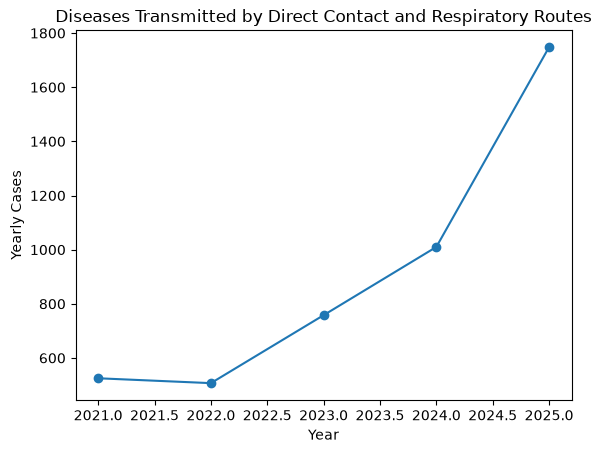

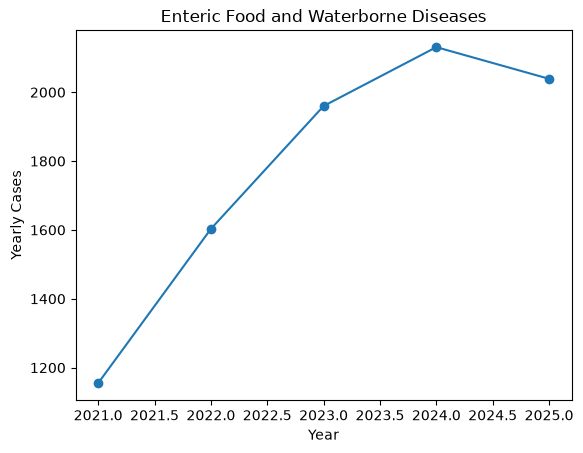

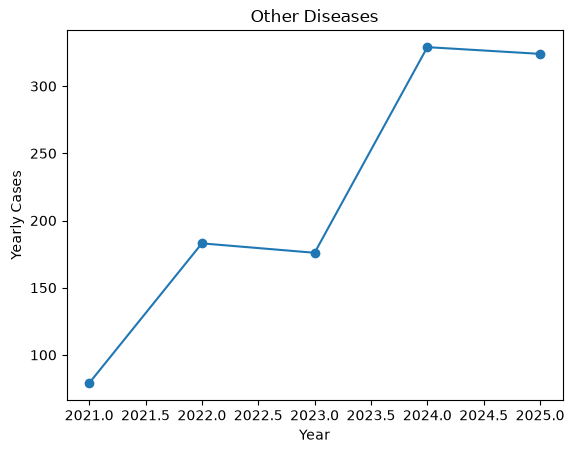

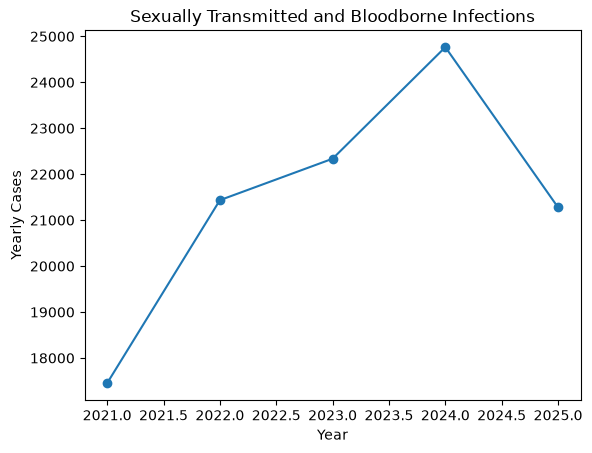

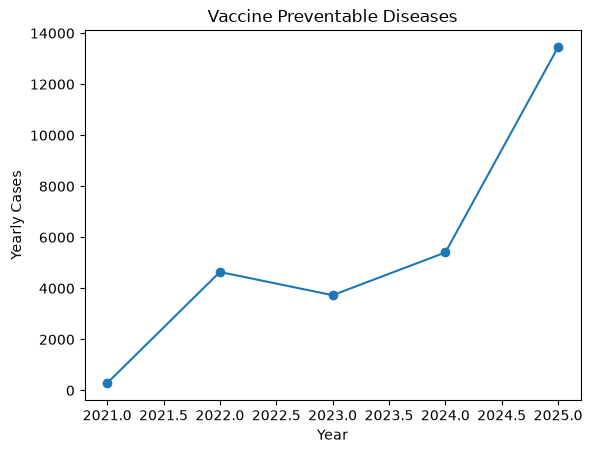

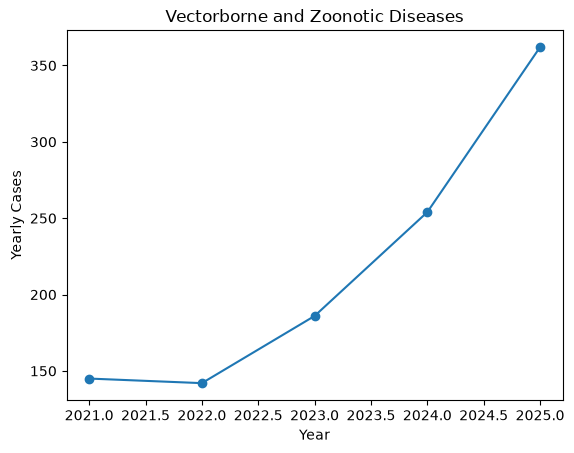

In [56]:
for cat in first_plot_data["Disease Category"].unique():
    cat_data = first_plot_data[first_plot_data["Disease Category"] == cat]
    
    plt.figure()
    plt.plot(
        cat_data["Year"],
        cat_data["Yearly Cases"], 
        marker = 'o'
    )
    plt.title(cat)
    plt.xlabel("Year")
    plt.ylabel("Yearly Cases")
    plt.show()

### Monthly category patterns
___

#### Reshape category counts by month


In [57]:
months = ["January", "February", "March", "April","May", "June", "July", "August", "September", "October", "November", "December"]

monthly_data = first_plot_data.melt(
    id_vars=["Disease Category", "Year"], value_vars=months, var_name="Month", value_name="Cases")

monthly_data["Date"] = pd.to_datetime(
    monthly_data["Year"].astype(str) + " " + monthly_data["Month"], format="%Y %B"
)
monthly_data

,Disease Category,Year,Month,Cases,Date
0,Diseases Transmitted by Direct Contact and Res...,2021,January,38.0,2021-01-01
1,Diseases Transmitted by Direct Contact and Res...,2022,January,41.0,2022-01-01
2,Diseases Transmitted by Direct Contact and Res...,2023,January,68.0,2023-01-01
3,Diseases Transmitted by Direct Contact and Res...,2024,January,76.0,2024-01-01
4,Diseases Transmitted by Direct Contact and Res...,2025,January,127.0,2025-01-01
...,...,...,...,...,...
355,Vectorborne and Zoonotic Diseases,2021,December,0.0,2021-12-01
356,Vectorborne and Zoonotic Diseases,2022,December,1.0,2022-12-01
357,Vectorborne and Zoonotic Diseases,2023,December,2.0,2023-12-01
358,Vectorborne and Zoonotic Diseases,2024,December,4.0,2024-12-01


#### Plot monthly category trends


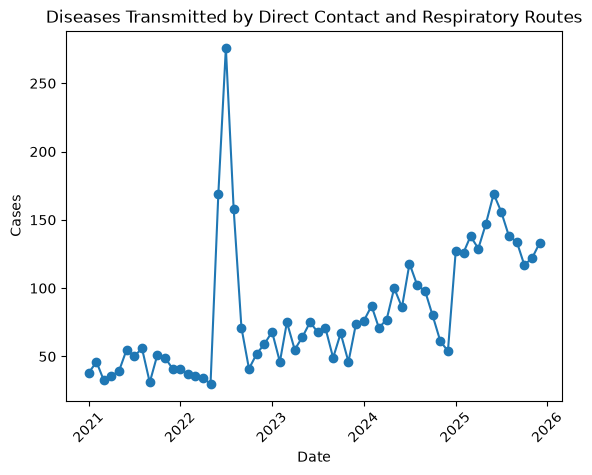

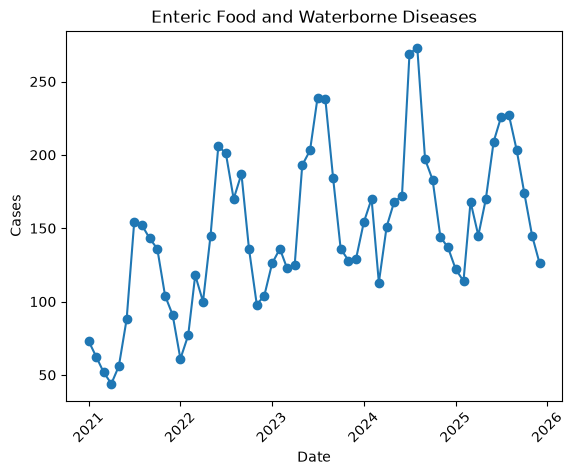

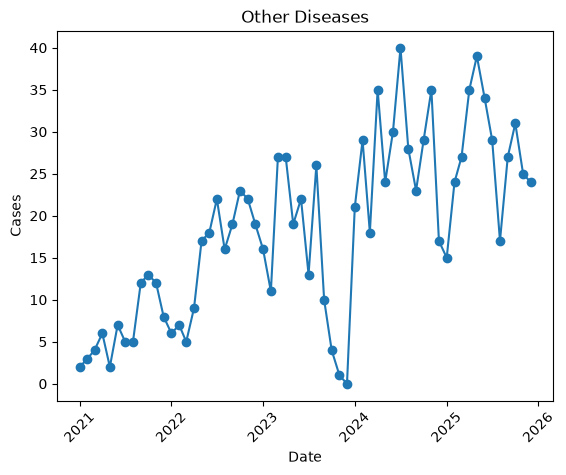

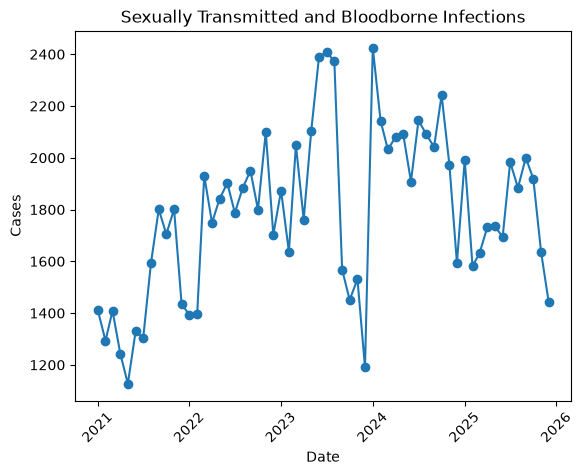

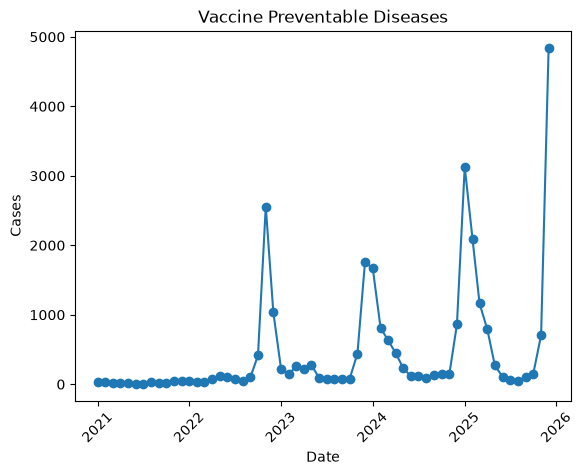

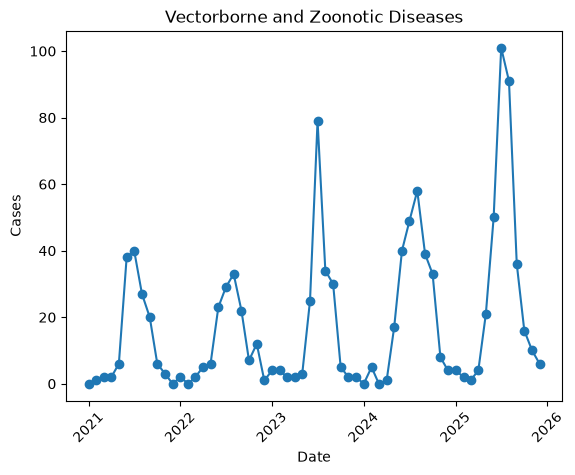

In [58]:
for cat in monthly_data["Disease Category"].unique():
    cat_data = monthly_data[monthly_data["Disease Category"] == cat].sort_values("Date")
    
    plt.plot(
        cat_data["Date"],
        cat_data["Cases"],
        marker="o"
    )

    plt.title(cat)
    plt.xlabel("Date")
    plt.ylabel("Cases")
    plt.xticks(rotation=45)

    plt.show()

## Vaccine-preventable diseases
___

#### Select vaccine-preventable diseases


In [59]:
vacc_data = data.loc[data["Disease Category"] == "Vaccine Preventable Diseases"].copy()
# Keep published rates such as <0.1 unchanged for threshold-aware plotting.
vacc_data.head(1)


,Disease Category,Disease,January,February,March,April,May,June,July,August,September,October,November,December,Yearly Cases,Yearly Rate,Year
190,Vaccine Preventable Diseases,Acute flaccid paralysis,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,2021


### Yearly rates by disease

Published `Yearly Rate` values for 2021?2025, with a separate vertical scale for each panel. Orange triangles mark upper thresholds (for example, `<0.1`), and missing observations remain gaps. Panels retain the source reporting category, including adverse vaccine reactions; rates are not summed across diseases.


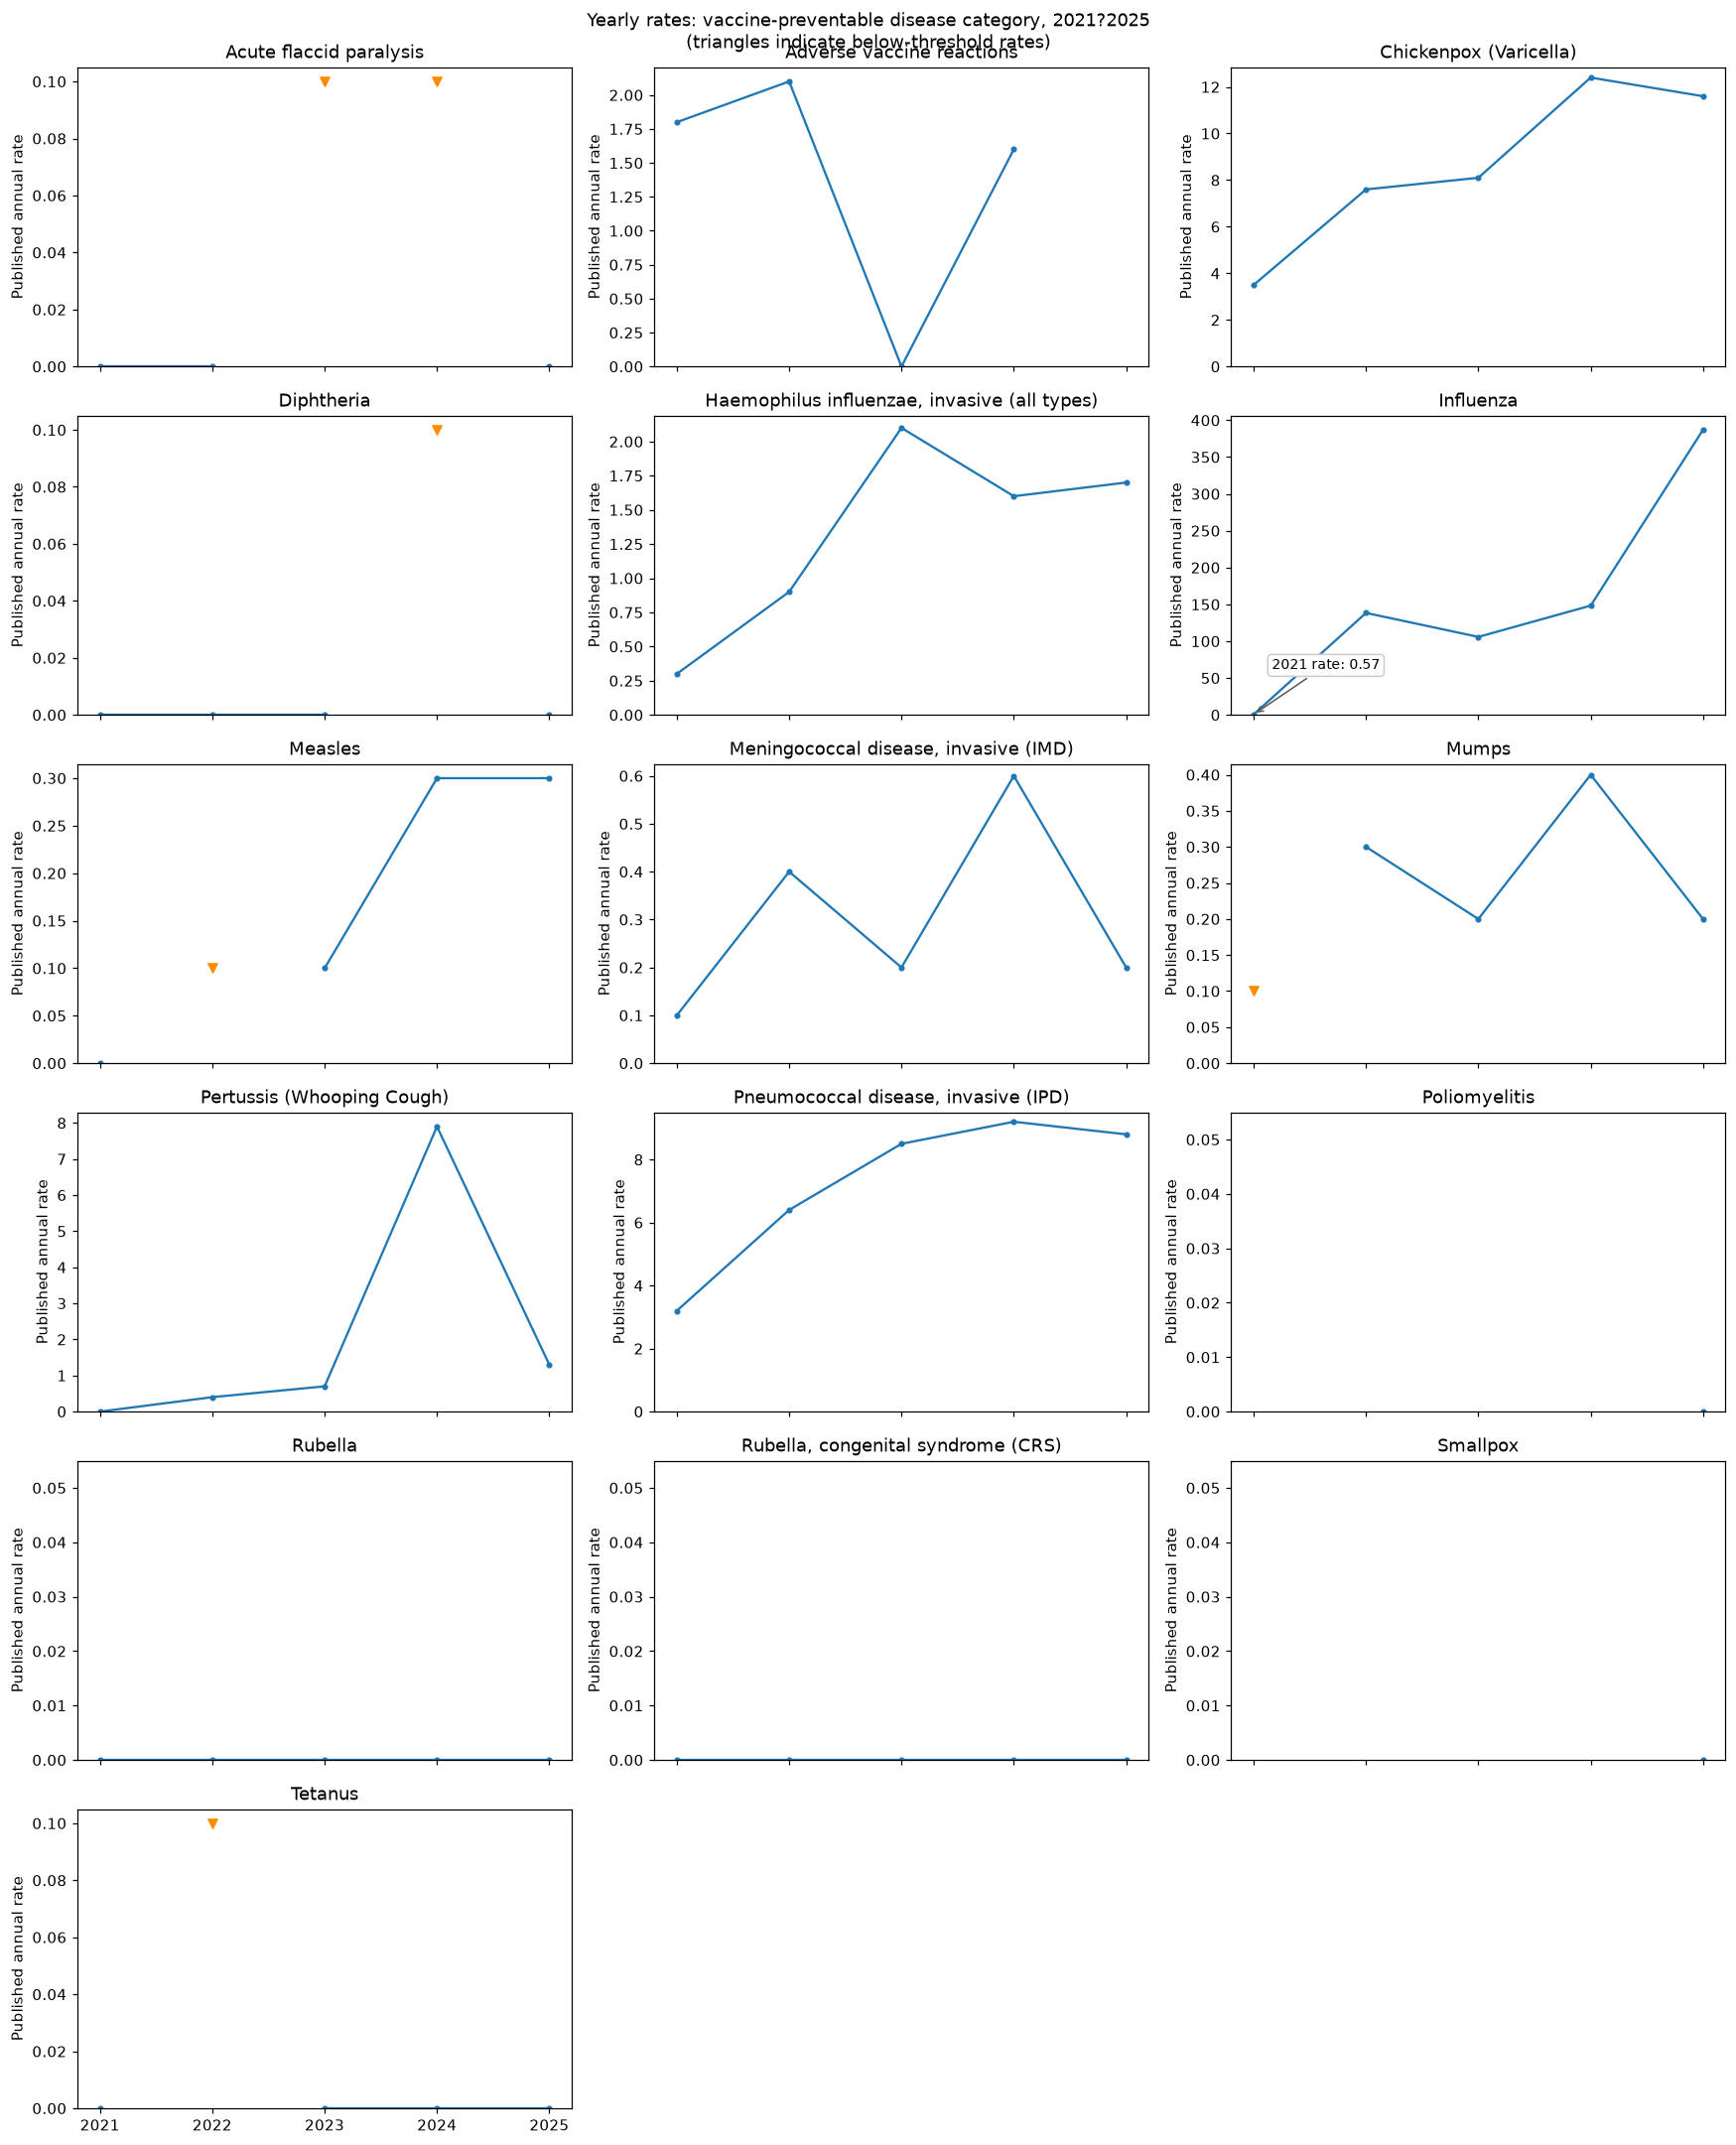

In [ ]:
vacc_names = sorted(vacc_data["Disease"].unique())
fig, axes = plt.subplots((len(vacc_names) + 2) // 3, 3, figsize=(16, 20), sharex=True)
for ax, disease in zip(axes.flat, vacc_names):
    group = vacc_data.loc[vacc_data["Disease"] == disease].set_index("Year").reindex(range(2021, 2026))
    text = group["Yearly Rate"].astype("string").str.strip()
    censored = text.str.startswith("<").fillna(False)
    rates = pd.to_numeric(text.str.lstrip("<"), errors="coerce")
    ax.plot(group.index, rates.mask(censored), marker="o", markersize=3)
    ax.scatter(group.index[censored], rates[censored], marker="v", color="darkorange")
    if disease == "Influenza" and pd.notna(rates.loc[2021]):
        ax.annotate(
            f"2021 rate: {rates.loc[2021]:.2f}",
            xy=(2021, rates.loc[2021]), xytext=(12, 30),
            textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="0.35"),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8"),
        )
    ax.set(title=disease, ylabel="Published annual rate")
    ax.set_xticks(range(2021, 2026))
    ax.set_ylim(bottom=0)
for ax in list(axes.flat)[len(vacc_names):]:
    ax.set_visible(False)
fig.suptitle("Yearly rates: vaccine-preventable disease category, 2021?2025\n(triangles indicate below-threshold rates)")
fig.tight_layout()
plt.show()
plt.close(fig)


### Monthly disease contributions

The individual-disease dates must come from `vacc_mon_data` itself. Assigning
`monthly_data` dates aligns unrelated row indices and leaves many dates missing.
The checks below verify that every disease-month has the correct date and that
individual counts reproduce the earlier category trend for all 60 months.
Annual totals are not used here: revised 2025 totals can differ from monthly sums.


#### Prepare disease-level monthly counts


In [60]:
vacc_mon_data = vacc_data.melt(
    id_vars=["Disease", "Year"], value_vars=months,
    var_name="Month", value_name="Cases"
)
# Build dates from THIS table, with an explicit format to avoid ambiguous parsing.
vacc_mon_data["Date"] = pd.to_datetime(
    vacc_mon_data["Year"].astype(str) + " " + vacc_mon_data["Month"],
    format="%Y %B"
)
assert vacc_mon_data["Date"].notna().all()
assert not vacc_mon_data.duplicated(["Disease", "Date"]).any()
vacc_mon_data = vacc_mon_data.sort_values(["Disease", "Date"])
vacc_mon_data.head()


,Disease,Year,Month,Cases,Date
0,Acute flaccid paralysis,2021,January,0.0,2021-01-01
71,Acute flaccid paralysis,2021,February,0.0,2021-02-01
142,Acute flaccid paralysis,2021,March,0.0,2021-03-01
213,Acute flaccid paralysis,2021,April,0.0,2021-04-01
284,Acute flaccid paralysis,2021,May,0.0,2021-05-01


#### Check category totals and identify peak contributions


In [61]:
# Reconcile individual diseases against the category totals plotted above.

category_totals = monthly_data.loc[
    monthly_data["Disease Category"] == "Vaccine Preventable Diseases"
].set_index("Date")["Cases"].sort_index()

# One column per disease makes each peak's composition easy to inspect.
contributions = vacc_mon_data.pivot(index="Date", columns="Disease", values="Cases")
peak_dates = category_totals.nlargest(10).index
peak_breakdown = contributions.loc[peak_dates].copy()
peak_breakdown.insert(0, "Category total", category_totals.loc[peak_dates])
peak_breakdown.insert(1, "Influenza share (%)",
                      (100 * peak_breakdown["Influenza"] / peak_breakdown["Category total"]).round(1))
peak_breakdown


Disease,Category total,Influenza share (%),Acute flaccid paralysis,Adverse vaccine reactions,Chickenpox (Varicella),Diphtheria,"Haemophilus influenzae, invasive (all types)",Influenza,Measles,"Meningococcal disease, invasive (IMD)",Mumps,Pertussis (Whooping Cough),"Pneumococcal disease, invasive (IPD)",Poliomyelitis,Rubella,"Rubella, congenital syndrome (CRS)",Smallpox,Tetanus
Date,,,,,,,,,,,,,,,,,,
2025-12-01,4843.0,98.5,0.0,NaN,24.0,0.0,5.0,4770.0,0.0,0.0,1.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0
2025-01-01,3129.0,97.4,0.0,NaN,41.0,0.0,5.0,3048.0,1.0,0.0,0.0,7.0,27.0,0.0,0.0,0.0,0.0,0.0
2022-11-01,2558.0,96.6,0.0,13.0,20.0,0.0,10.0,2471.0,0.0,2.0,2.0,3.0,37.0,NaN,0.0,0.0,NaN,0.0
2025-02-01,2093.0,96.3,0.0,NaN,34.0,0.0,4.0,2015.0,0.0,0.0,0.0,3.0,37.0,0.0,0.0,0.0,0.0,0.0
2023-12-01,1759.0,96.4,0.0,0.0,3.0,0.0,15.0,1696.0,0.0,0.0,2.0,1.0,42.0,NaN,0.0,0.0,NaN,0.0
2024-01-01,1666.0,94.5,0.0,0.0,39.0,0.0,8.0,1575.0,0.0,0.0,2.0,14.0,28.0,NaN,0.0,0.0,NaN,0.0
2025-03-01,1163.0,94.9,0.0,NaN,24.0,0.0,2.0,1104.0,2.0,0.0,2.0,4.0,25.0,0.0,0.0,0.0,0.0,0.0
2022-12-01,1040.0,94.1,0.0,2.0,21.0,0.0,6.0,979.0,0.0,0.0,2.0,1.0,29.0,NaN,0.0,0.0,NaN,0.0
2024-12-01,861.0,90.6,0.0,4.0,29.0,0.0,4.0,780.0,1.0,1.0,0.0,12.0,30.0,NaN,0.0,0.0,NaN,0.0


#### Plot monthly cases for each disease


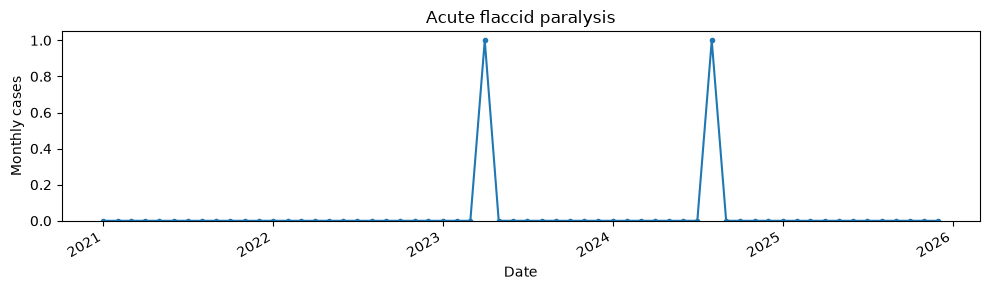

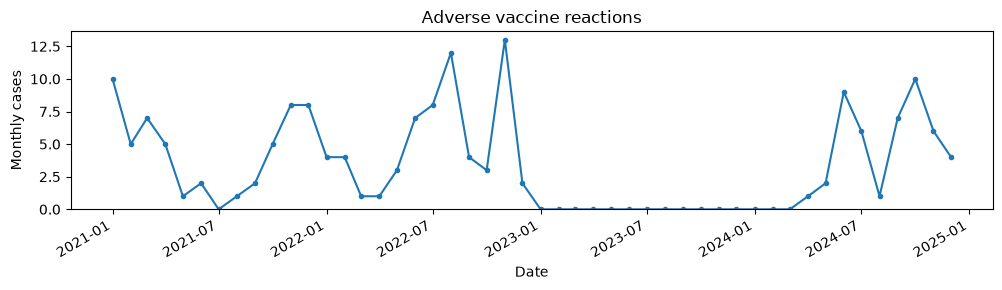

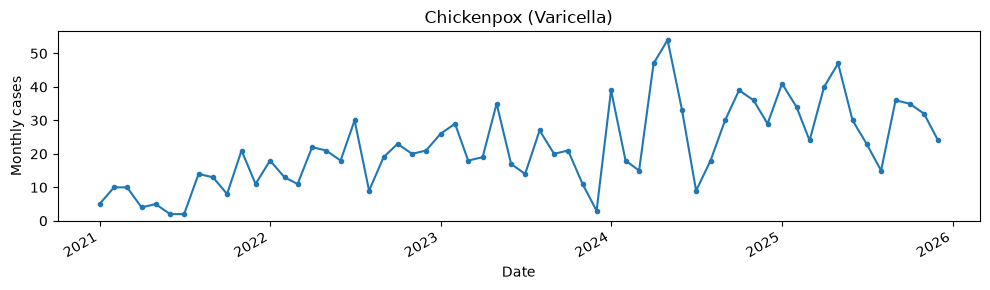

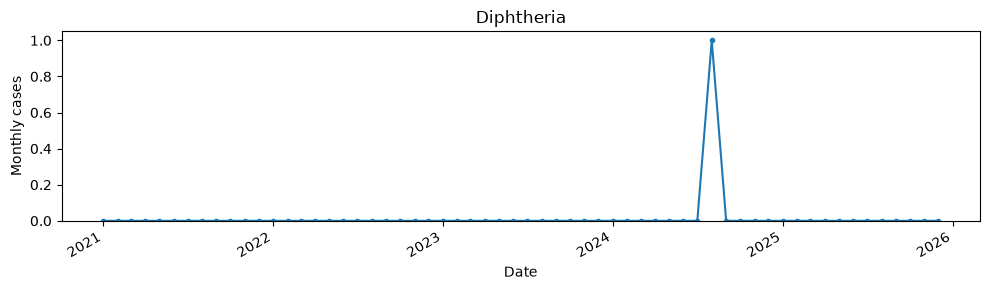

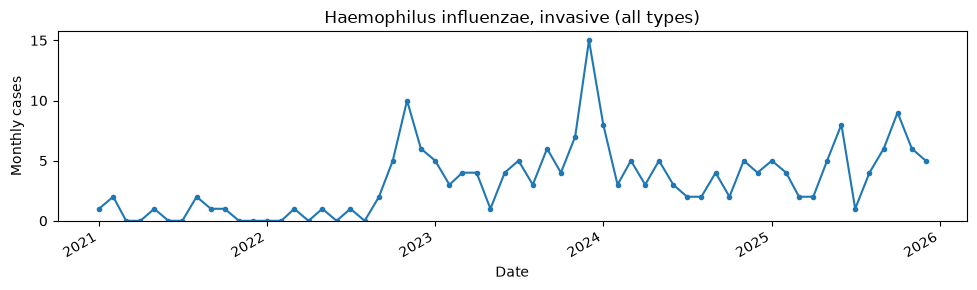

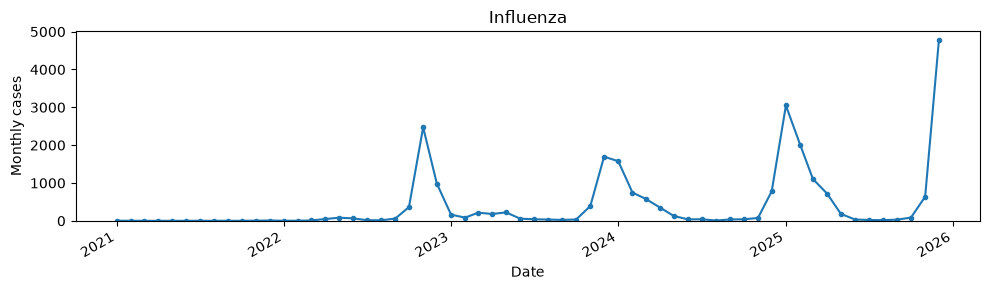

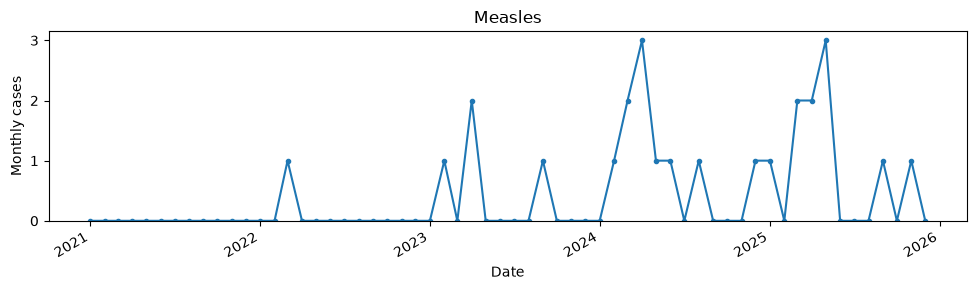

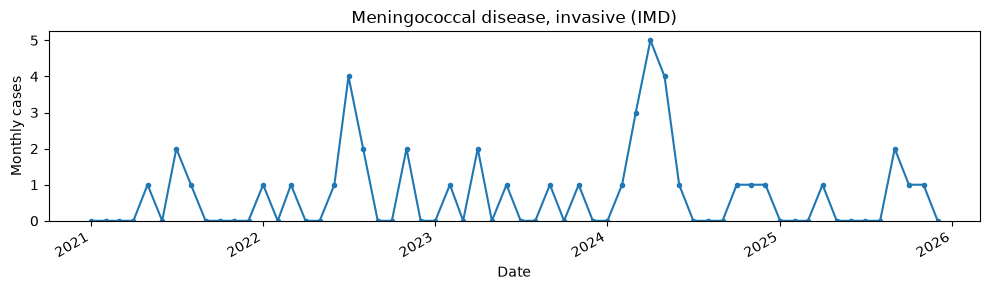

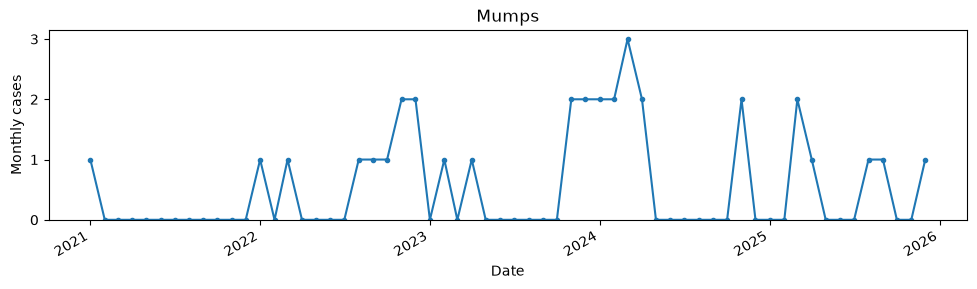

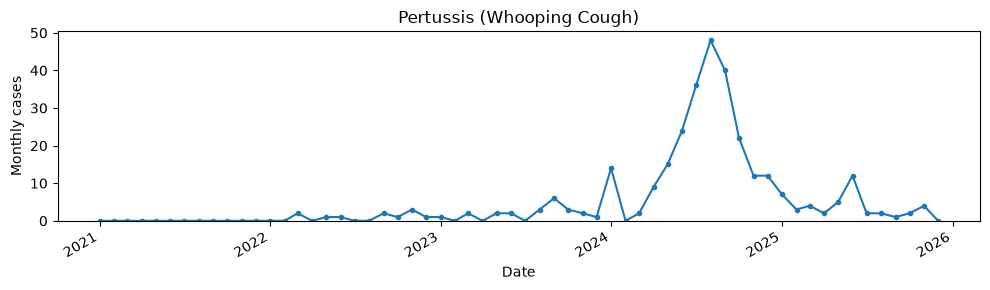

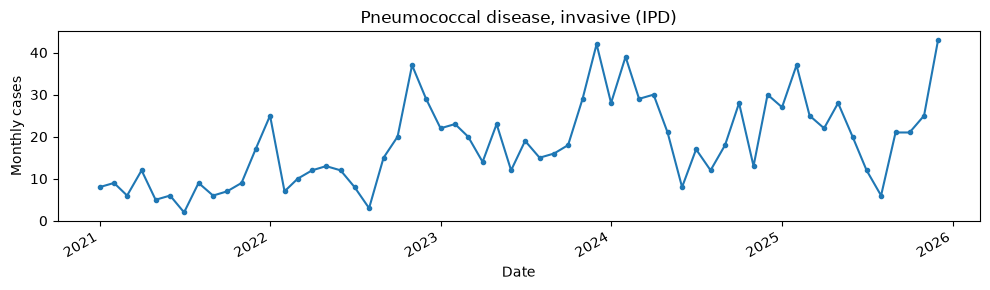

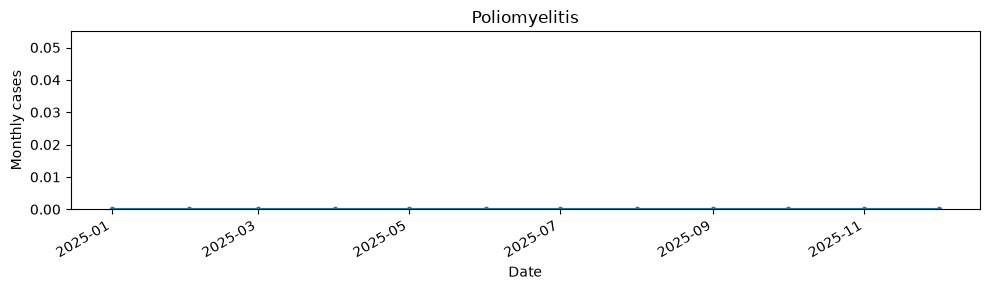

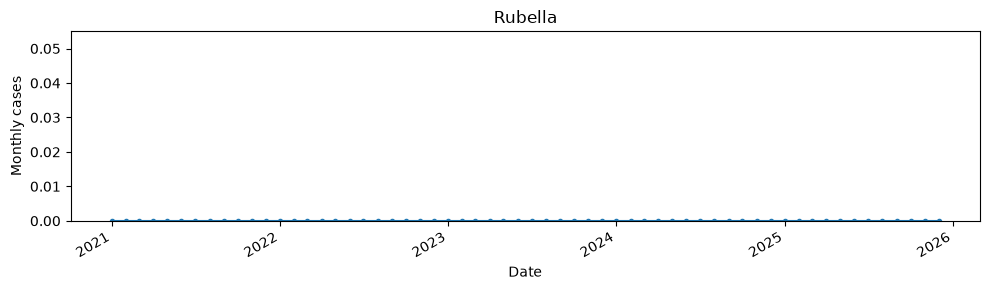

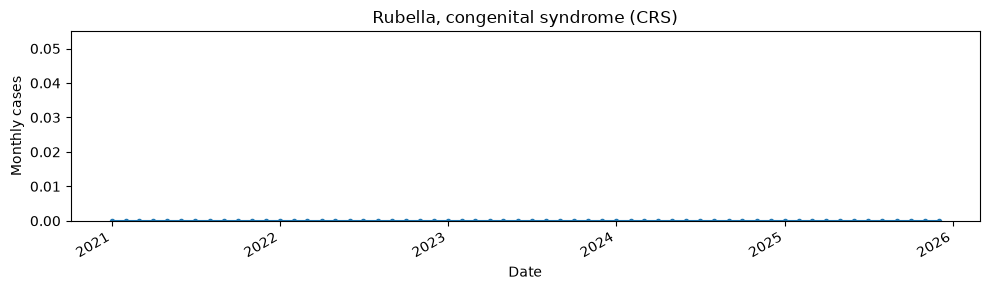

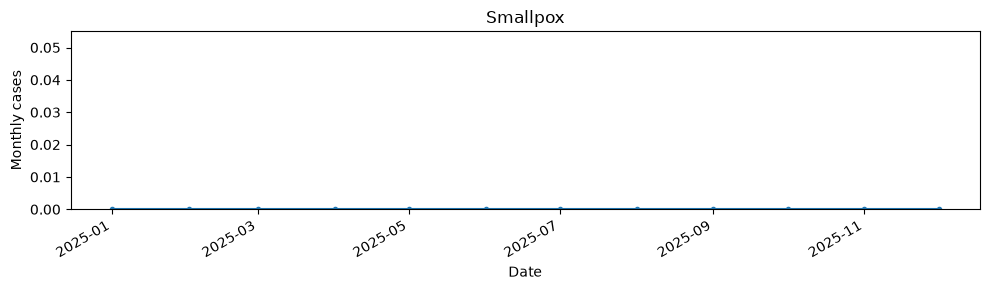

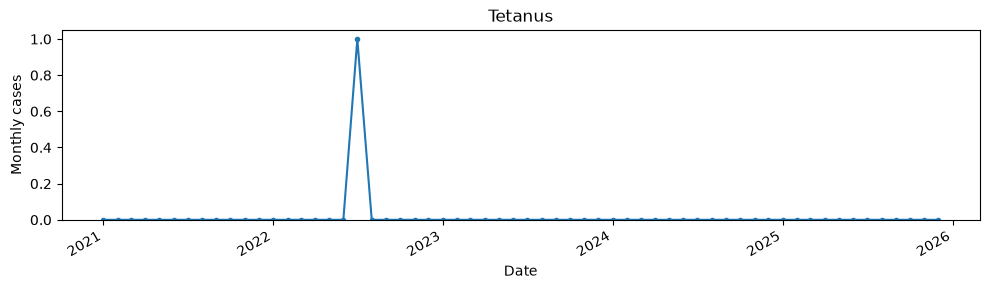

In [62]:
# Separate figures reveal each disease's timing on its own vertical scale.
# Compare absolute contributions using the stacked plot below.
for disease, disease_data in vacc_mon_data.groupby("Disease", sort=True):
    disease_data = disease_data.sort_values("Date")
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(disease_data["Date"], disease_data["Cases"], marker="o", markersize=3)
    ax.set(title=disease, xlabel="Date", ylabel="Monthly cases")
    ax.set_ylim(bottom=0)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Vectorborne and zoonotic diseases

Monthly counts show the timing and size of reported case peaks. The rate plots
use **annual published rates**, since monthly rates and matching population
denominators are not supplied in the cleaned dataset. We do not divide annual
rates by twelve or infer populations from rounded rates. Monthly rates would
require a verified population denominator for each year and reporting group.
Missing observations remain gaps; rates such as `<0.1` are shown as thresholds.


#### Prepare vectorborne disease observations


In [63]:
vector_data = data.loc[
    data["Disease Category"] == "Vectorborne and Zoonotic Diseases"
].copy()
vector_monthly = vector_data.melt(
    id_vars=["Disease", "Year"], value_vars=months,
    var_name="Month", value_name="Cases"
)
vector_monthly["Date"] = pd.to_datetime(
    vector_monthly["Year"].astype(str) + " " + vector_monthly["Month"],
    format="%Y %B"
)
vector_monthly = vector_monthly.sort_values(["Disease", "Date"])
assert not vector_monthly.duplicated(["Disease", "Date"]).any()
vector_monthly.head()


,Disease,Year,Month,Cases,Date
0,Anaplasmosis,2023,January,NaN,2023-01-01
54,Anaplasmosis,2023,February,NaN,2023-02-01
108,Anaplasmosis,2023,March,NaN,2023-03-01
162,Anaplasmosis,2023,April,NaN,2023-04-01
216,Anaplasmosis,2023,May,NaN,2023-05-01


#### Compare monthly case trends by disease

Each panel uses its own vertical scale to reveal timing in less common diseases.


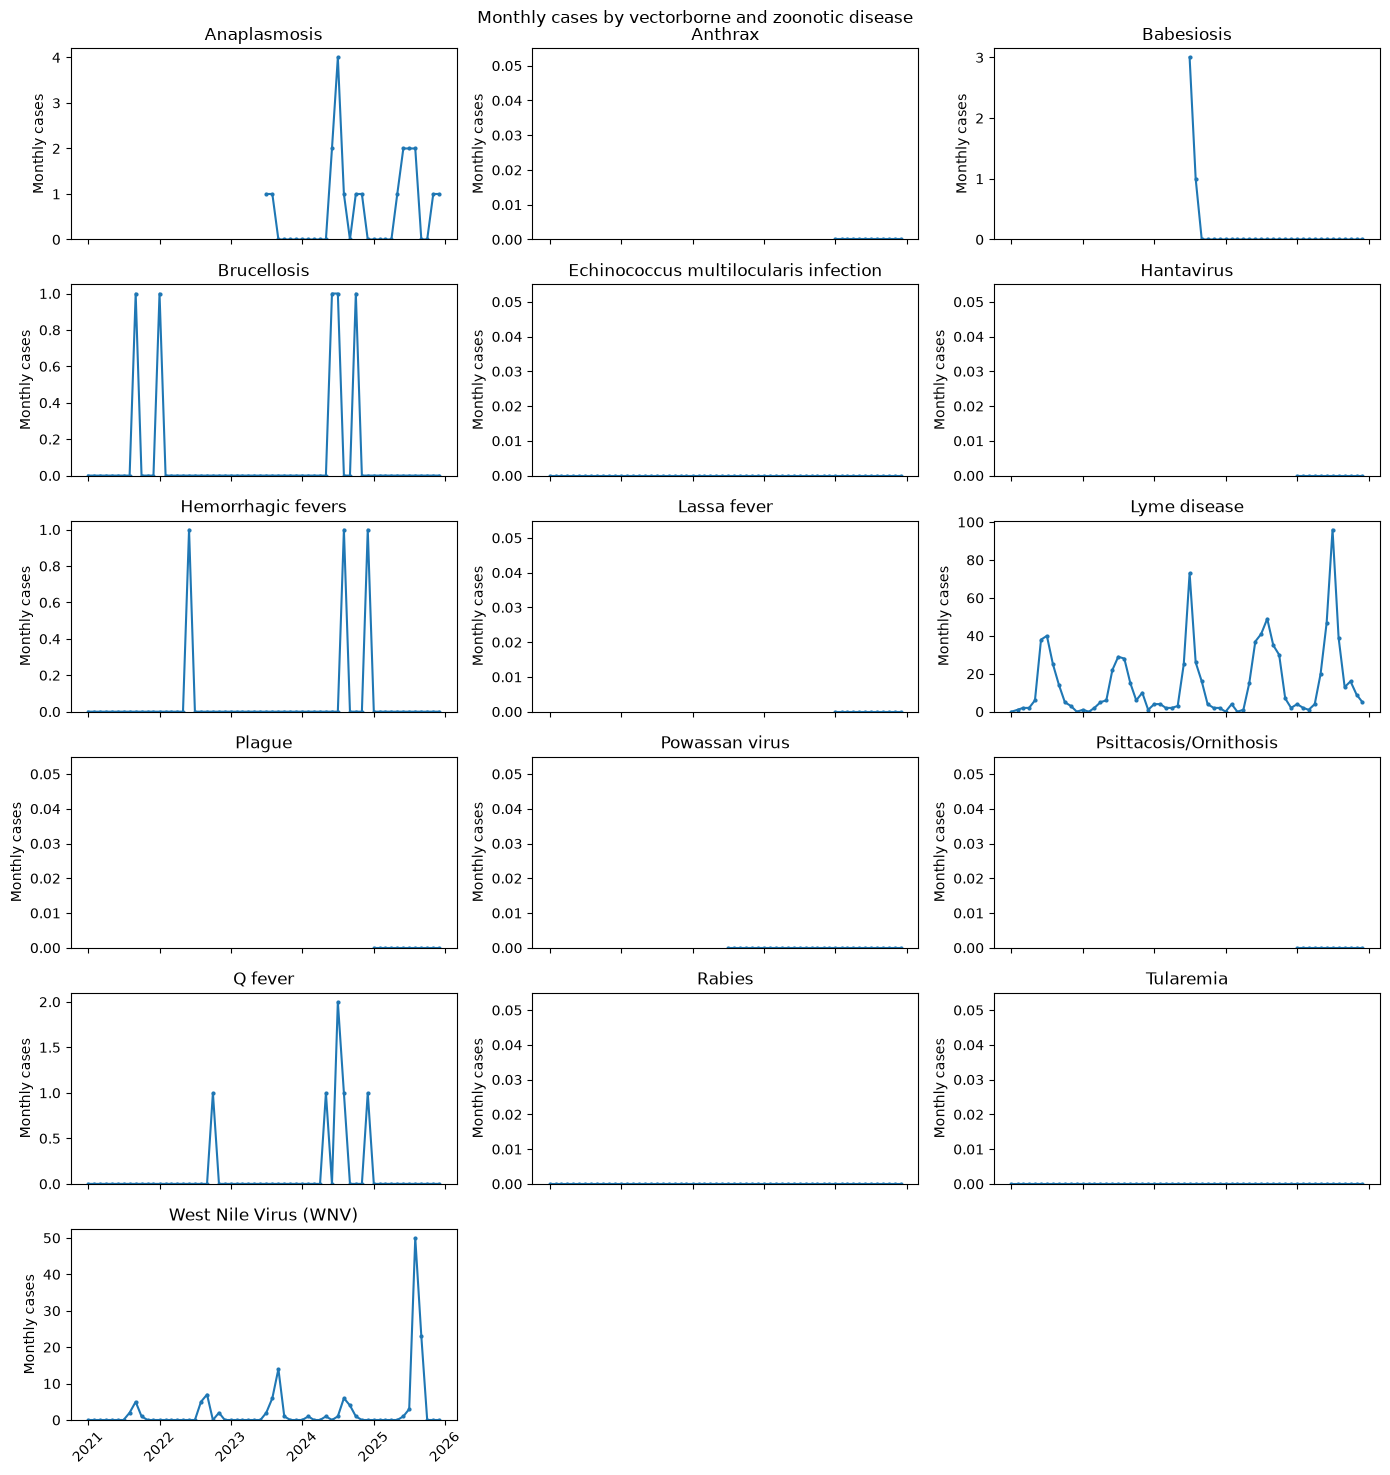

In [65]:
dates = pd.date_range("2021-01-01", "2025-12-01", freq="MS")
vector_names = sorted(vector_data["Disease"].unique())
fig, axes = plt.subplots((len(vector_names) + 2) // 3, 3, figsize=(14, 15), sharex=True)
for ax, disease in zip(axes.flat, vector_names):
    series = vector_monthly.loc[vector_monthly["Disease"] == disease].set_index("Date")["Cases"]
    # Reindexing preserves gaps for years when a disease was not listed.
    series = series.reindex(dates)
    ax.plot(series.index, series, marker="o", markersize=2)
    ax.set(title=disease, ylabel="Monthly cases")
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="x", rotation=45)
for ax in list(axes.flat)[len(vector_names):]:
    ax.set_visible(False)
fig.suptitle("Monthly cases by vectorborne and zoonotic disease")
fig.tight_layout()
plt.show()
plt.close(fig)


#### Compare annual published rates by disease

Triangles mark an upper threshold, not an exact rate. Annual rates are not summed across diseases.


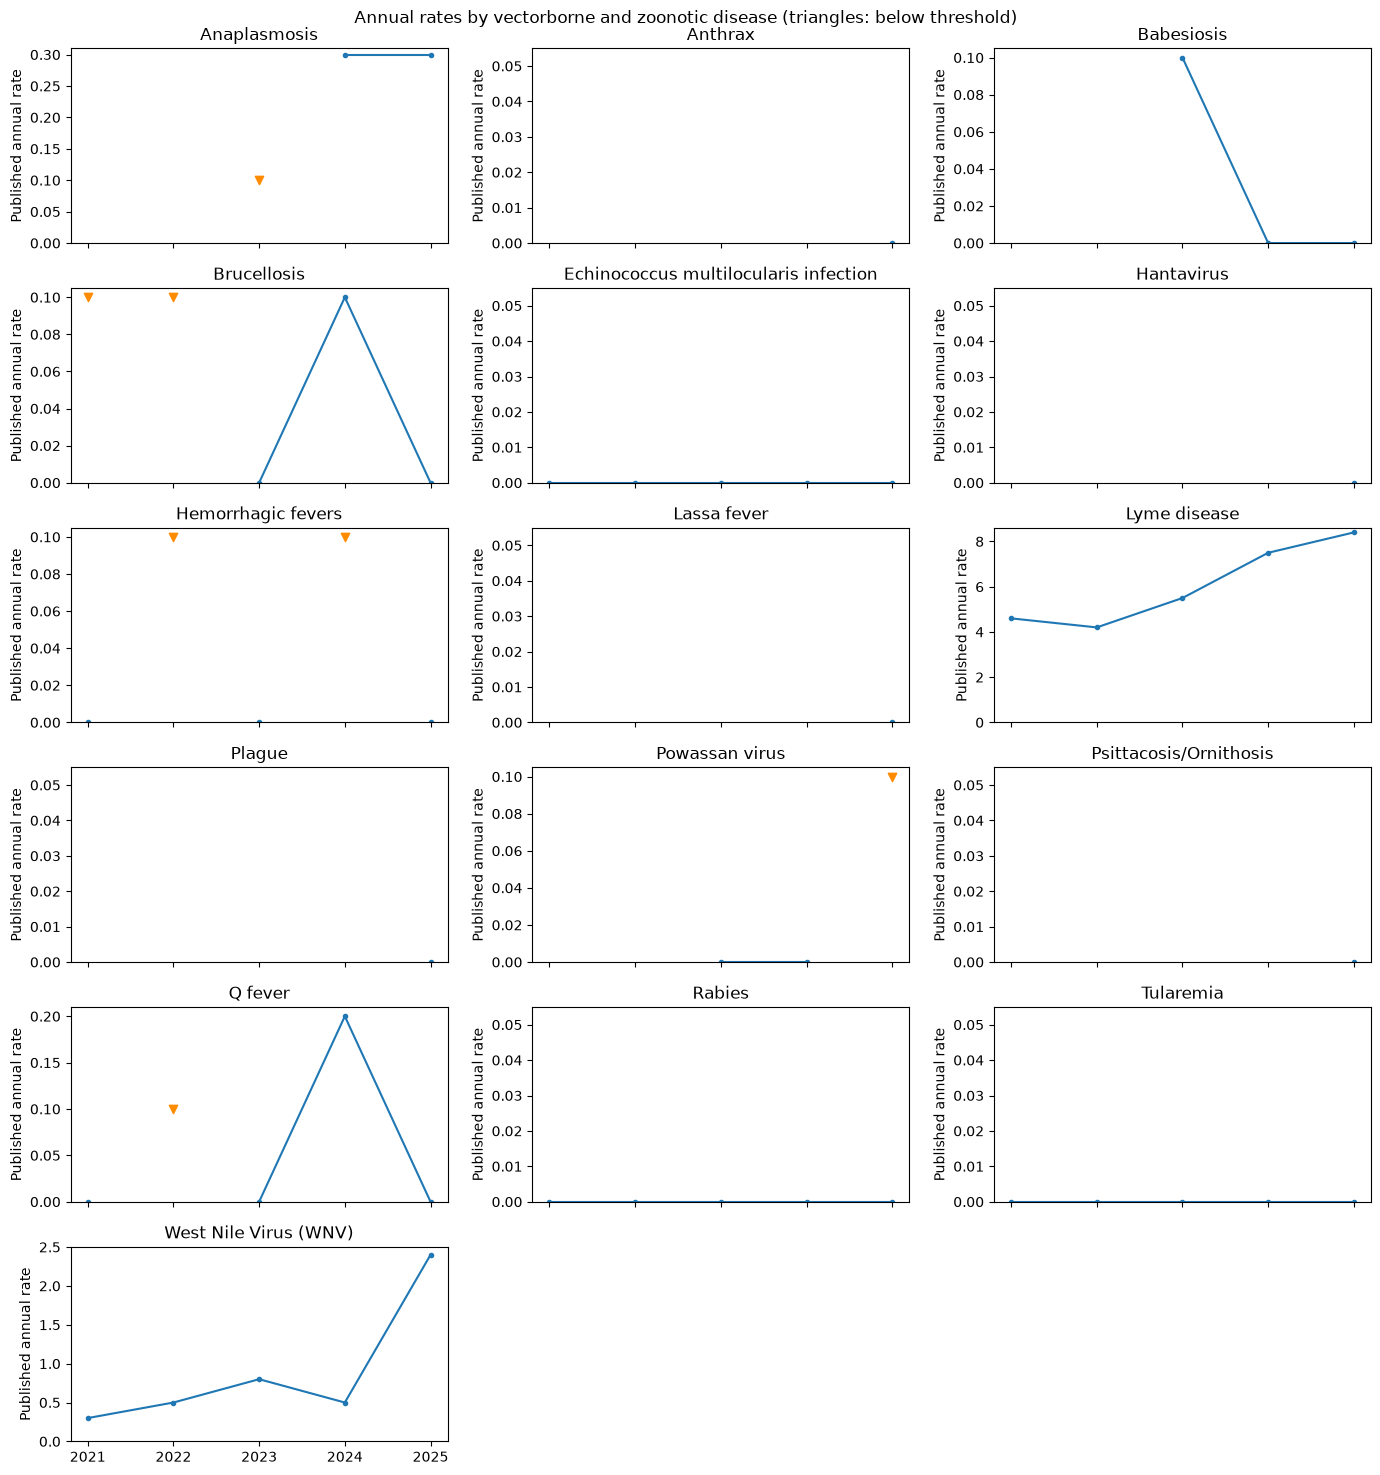

In [66]:
fig, axes = plt.subplots((len(vector_names) + 2) // 3, 3, figsize=(14, 15), sharex=True)
for ax, disease in zip(axes.flat, vector_names):
    group = vector_data.loc[vector_data["Disease"] == disease].set_index("Year").reindex(range(2021, 2026))
    text = group["Yearly Rate"].astype("string").str.strip()
    censored = text.str.startswith("<").fillna(False)
    rates = pd.to_numeric(text.str.lstrip("<"), errors="coerce")
    ax.plot(group.index, rates.mask(censored), marker="o", markersize=3)
    ax.scatter(group.index[censored], rates[censored], marker="v", color="darkorange")
    ax.set(title=disease, ylabel="Published annual rate")
    ax.set_xticks(range(2021, 2026))
    ax.set_ylim(bottom=0)
for ax in list(axes.flat)[len(vector_names):]:
    ax.set_visible(False)
fig.suptitle("Annual rates by vectorborne and zoonotic disease (triangles: below threshold)")
fig.tight_layout()
plt.show()
plt.close(fig)


## Enteric, food and waterborne diseases


#### Prepare enteric disease observations


In [67]:
enteric_data = data.loc[
    data["Disease Category"] == "Enteric Food and Waterborne Diseases"
].copy()
enteric_monthly = enteric_data.melt(
    id_vars=["Disease", "Year"], value_vars=months,
    var_name="Month", value_name="Cases"
)
enteric_monthly["Date"] = pd.to_datetime(
    enteric_monthly["Year"].astype(str) + " " + enteric_monthly["Month"],
    format="%Y %B"
)
enteric_monthly = enteric_monthly.sort_values(["Disease", "Date"])
assert not enteric_monthly.duplicated(["Disease", "Date"]).any()
enteric_monthly.head()


,Disease,Year,Month,Cases,Date
0,Amebiasis,2021,January,6.0,2021-01-01
90,Amebiasis,2021,February,4.0,2021-02-01
180,Amebiasis,2021,March,4.0,2021-03-01
270,Amebiasis,2021,April,8.0,2021-04-01
360,Amebiasis,2021,May,2.0,2021-05-01


#### Plot monthly category case totals


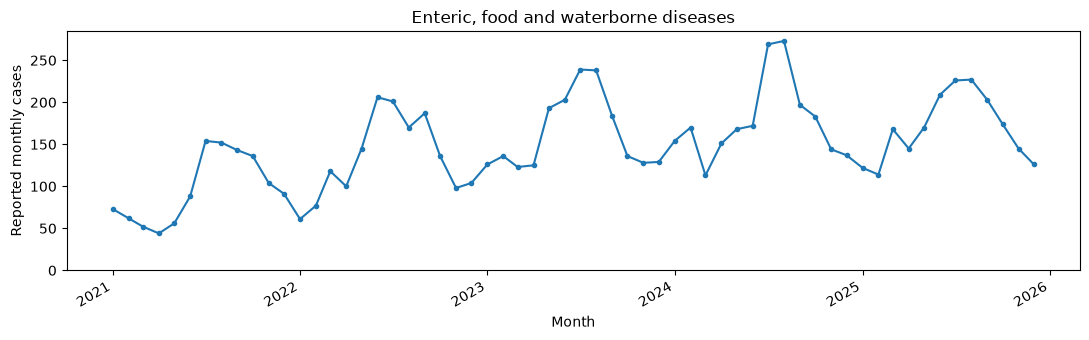

In [68]:
# Keep an unknown total if a reported monthly count is missing.
enteric_totals = enteric_monthly.groupby("Date")["Cases"].agg(
    lambda values: values.sum(min_count=len(values))
)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(enteric_totals.index, enteric_totals, marker="o", markersize=3)
ax.set(title="Enteric, food and waterborne diseases", xlabel="Month", ylabel="Reported monthly cases")
ax.set_ylim(bottom=0)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()
plt.close(fig)


#### Compare monthly case trends by disease


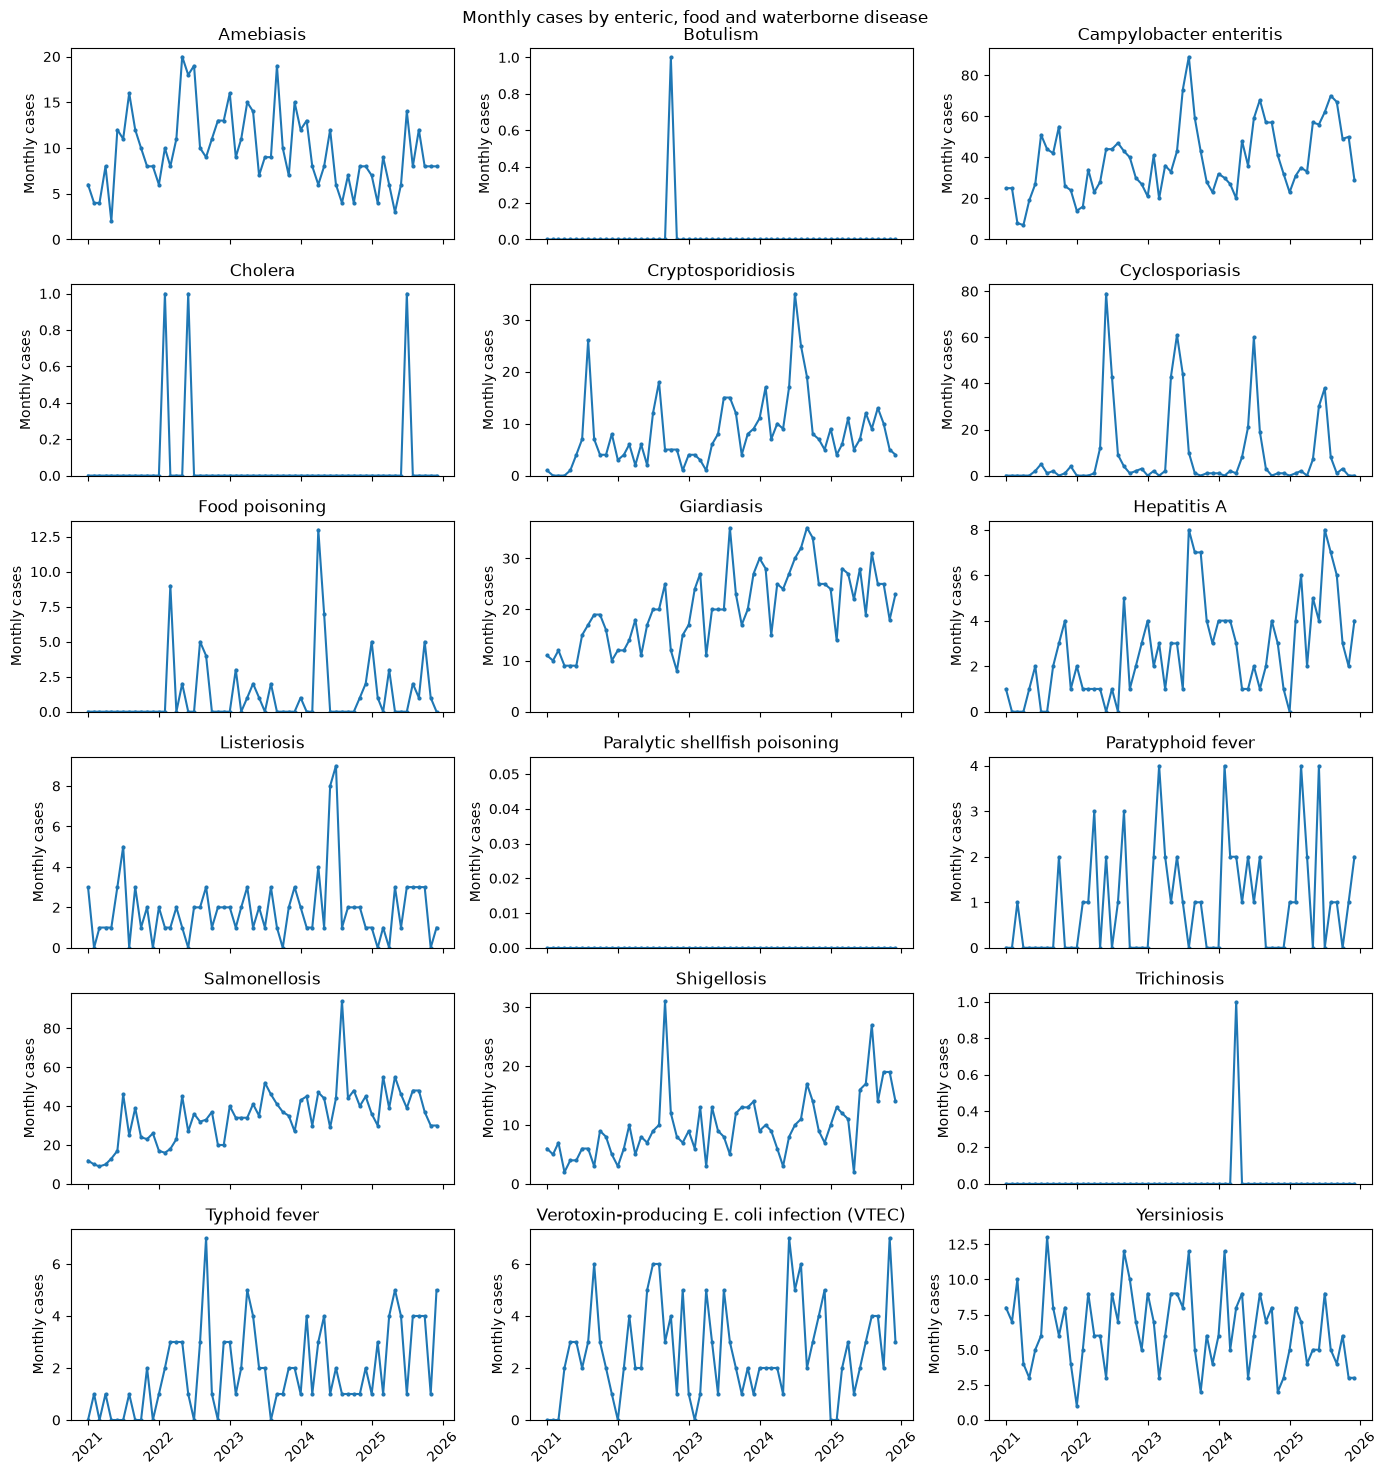

In [69]:
dates = pd.date_range("2021-01-01", "2025-12-01", freq="MS")
enteric_names = sorted(enteric_data["Disease"].unique())
fig, axes = plt.subplots((len(enteric_names) + 2) // 3, 3, figsize=(14, 15), sharex=True)
for ax, disease in zip(axes.flat, enteric_names):
    series = enteric_monthly.loc[enteric_monthly["Disease"] == disease].set_index("Date")["Cases"]
    # Reindexing preserves gaps for years when a disease was not listed.
    series = series.reindex(dates)
    ax.plot(series.index, series, marker="o", markersize=2)
    ax.set(title=disease, ylabel="Monthly cases")
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="x", rotation=45)
for ax in list(axes.flat)[len(enteric_names):]:
    ax.set_visible(False)
fig.suptitle("Monthly cases by enteric, food and waterborne disease")
fig.tight_layout()
plt.show()
plt.close(fig)


#### Compare annual published rates by disease


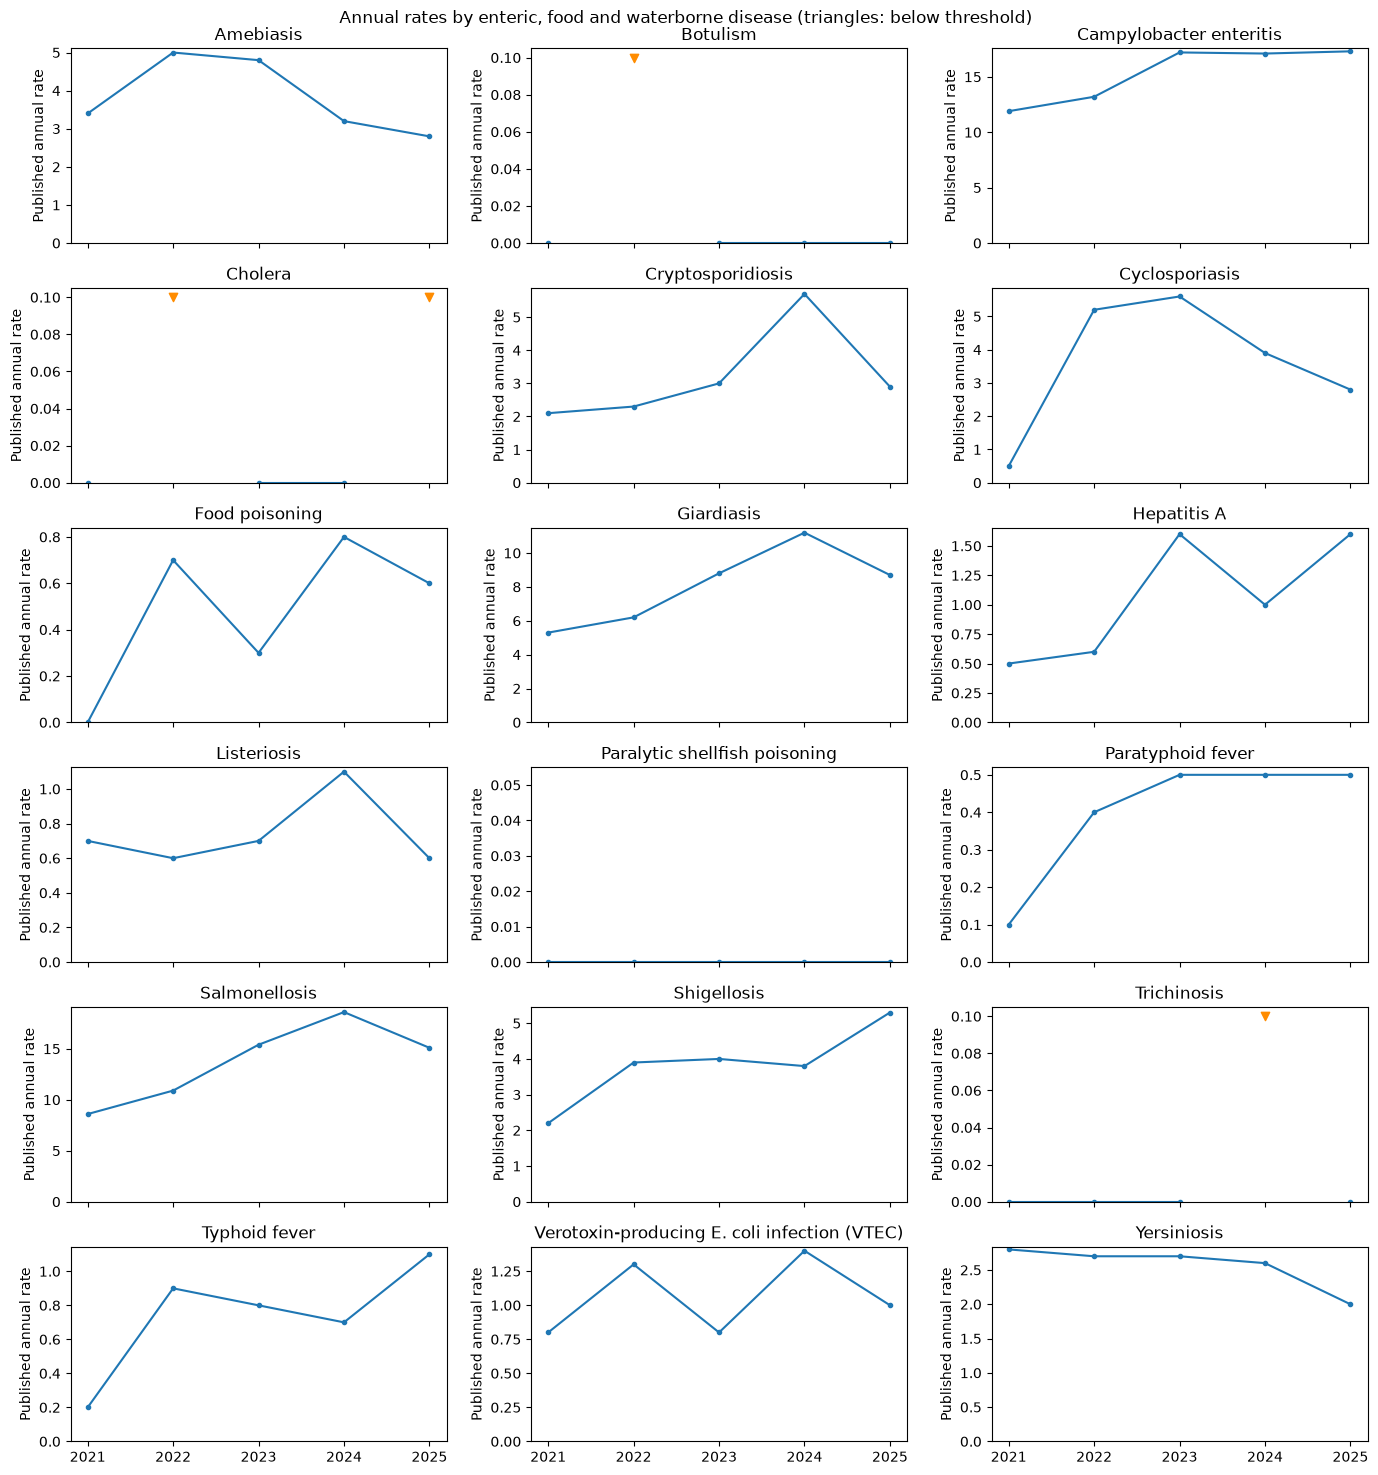

In [70]:
fig, axes = plt.subplots((len(enteric_names) + 2) // 3, 3, figsize=(14, 15), sharex=True)
for ax, disease in zip(axes.flat, enteric_names):
    group = enteric_data.loc[enteric_data["Disease"] == disease].set_index("Year").reindex(range(2021, 2026))
    text = group["Yearly Rate"].astype("string").str.strip()
    censored = text.str.startswith("<").fillna(False)
    rates = pd.to_numeric(text.str.lstrip("<"), errors="coerce")
    ax.plot(group.index, rates.mask(censored), marker="o", markersize=3)
    ax.scatter(group.index[censored], rates[censored], marker="v", color="darkorange")
    ax.set(title=disease, ylabel="Published annual rate")
    ax.set_xticks(range(2021, 2026))
    ax.set_ylim(bottom=0)
for ax in list(axes.flat)[len(enteric_names):]:
    ax.set_visible(False)
fig.suptitle("Annual rates by enteric, food and waterborne disease (triangles: below threshold)")
fig.tight_layout()
plt.show()
plt.close(fig)
